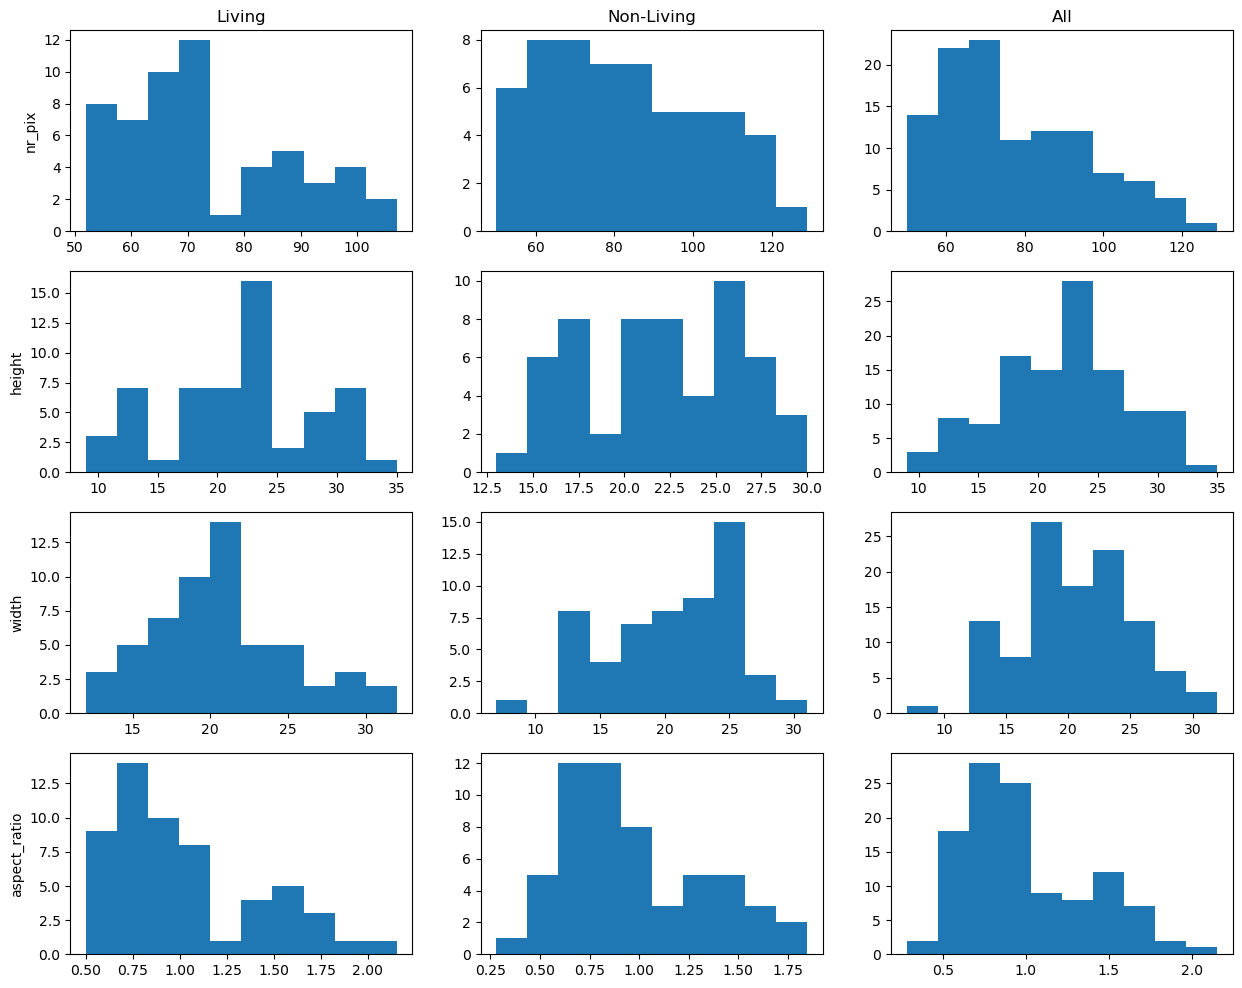

mean: 77.31
variance: 342.97
sd: 18.52


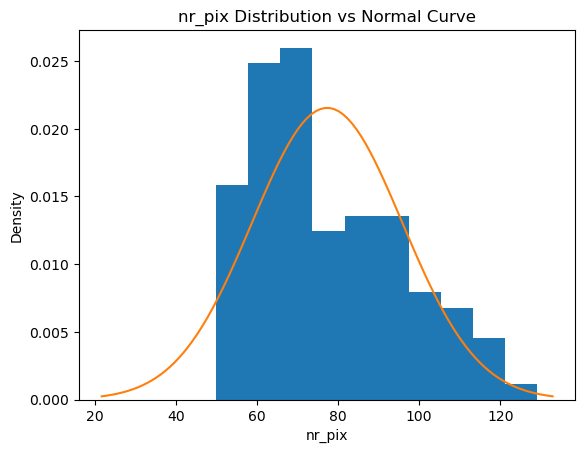

mean: 77.31
variance: 342.97
sd: 18.52
Cutoff value: 107.77


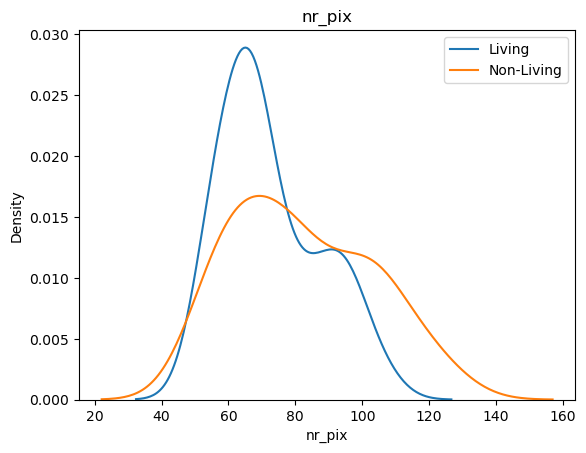

for nr_pix:
P-value: 0.006000


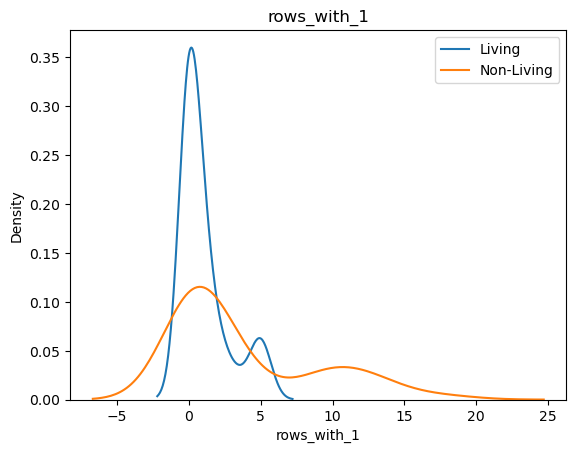

for rows_with_1:
P-value: 0.000171


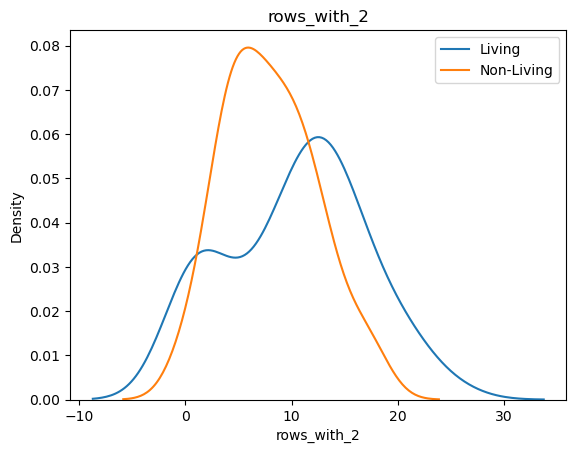

for rows_with_2:
P-value: 0.021156


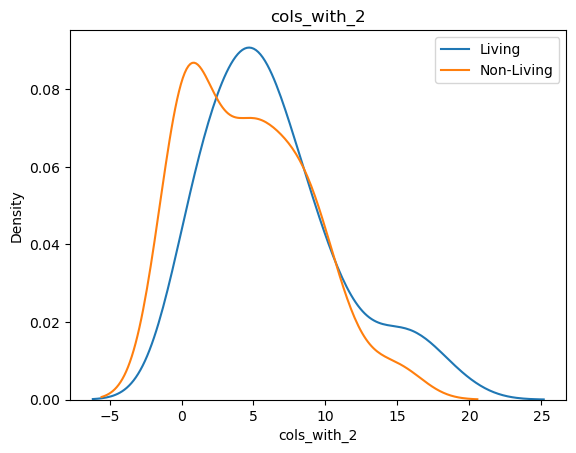

for cols_with_2:
P-value: 0.038299


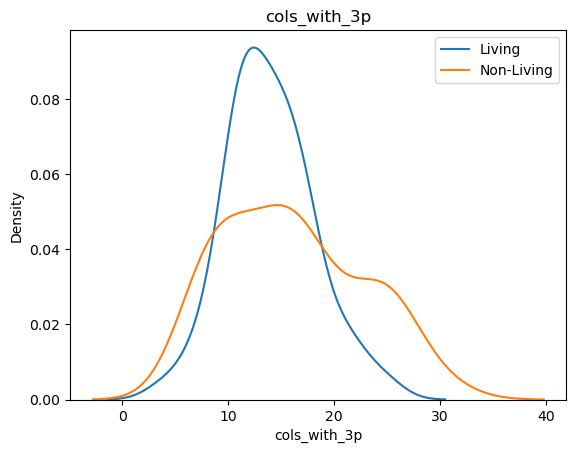

for cols_with_3p:
P-value: 0.038293


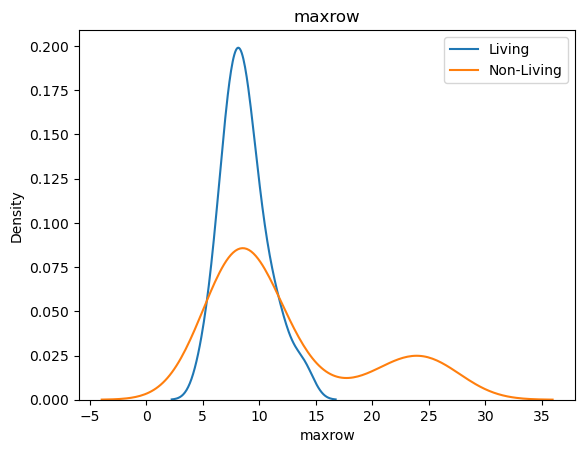

for maxrow:
P-value: 0.000200


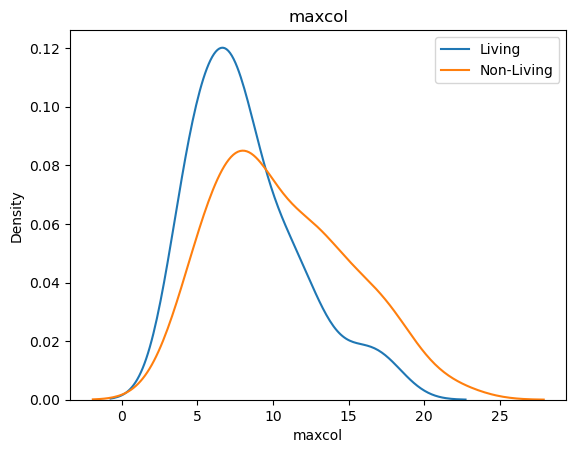

for maxcol:
P-value: 0.001822


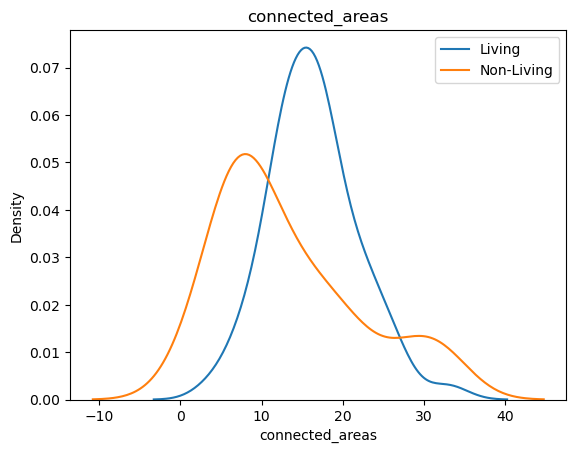

for connected_areas:
P-value: 0.025775


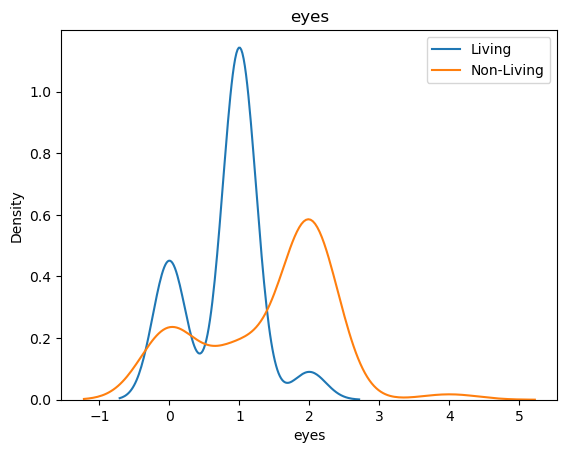

for eyes:
P-value: 0.000021


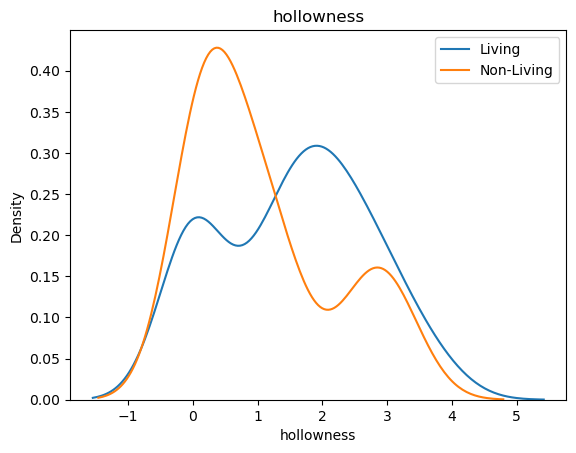

for hollowness:
P-value: 0.025311
                nr_pix    height     width  aspect_ratio  hollowness
nr_pix        1.000000  0.146095  0.630543      0.298516    0.219918
height        0.146095  1.000000  0.004254     -0.755253   -0.435907
width         0.630543  0.004254  1.000000      0.606663    0.279276
aspect_ratio  0.298516 -0.755253  0.606663      1.000000    0.471501
hollowness    0.219918 -0.435907  0.279276      0.471501    1.000000


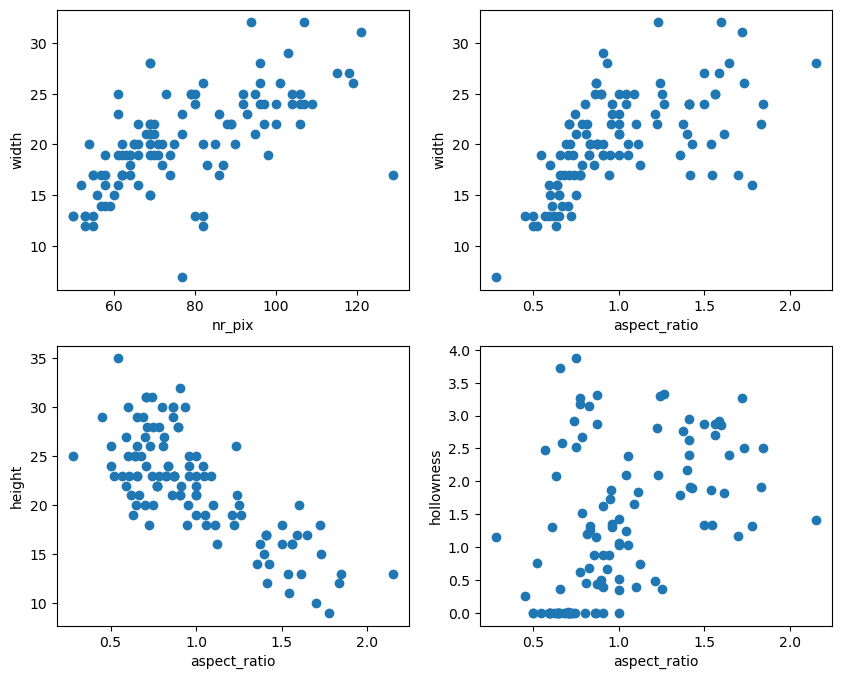

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm, ttest_ind 
import numpy as np

def main():

    src = "C:\\Users\\ammar\\Desktop\\A1_Ammar_Jileidan_40450780\\40450780_features.csv"
    
    df = pd.read_csv(src)
    
    livingThings = ["cherry", "banana", "lemon", "tree"]
    living = df[df["label"].isin(livingThings)]
    
    nonlivingThings = ["envelope", "golfclub", "pencil", "wineglass"]
    nonliving = df[df["label"].isin(nonlivingThings)]
    
    # Task 3.1
    # for the histograms
    fig, axes = plt.subplots(4, 3, figsize=(15, 12))
    
    axes[0][0].set_title("Living")
    axes[0][1].set_title("Non-Living")
    axes[0][2].set_title("All")
    
    axes[0][0].set_ylabel("nr_pix")
    axes[1][0].set_ylabel("height")
    axes[2][0].set_ylabel("width")
    axes[3][0].set_ylabel("aspect_ratio")
    
    
    axes[0][0].hist(living["nr_pix"])
    axes[1][0].hist(living["height"])
    axes[2][0].hist(living["width"])
    axes[3][0].hist(living["aspect_ratio"])

    axes[0][1].hist(nonliving["nr_pix"])
    axes[1][1].hist(nonliving["height"])
    axes[2][1].hist(nonliving["width"])
    axes[3][1].hist(nonliving["aspect_ratio"])
    
    axes[0][2].hist(df["nr_pix"])
    axes[1][2].hist(df["height"])
    axes[2][2].hist(df["width"])
    axes[3][2].hist(df["aspect_ratio"])
    
    plt.show()
    
    #Task 3.2
    # calaculate mean and variance
    mean = df["nr_pix"].mean()
    variance = df["nr_pix"].var()
    
    # calculate the standard deviation
    sd = np.sqrt(variance)

    print(f"mean: {mean:.2f}")
    print(f"variance: {variance:.2f}")
    print(f"sd: {sd:.2f}")
    
    # creates 100 evenly spaced points between + and - 3 SDs 
    #for the theoritacal normal distripution 
    x = np.linspace(mean - 3*sd, mean + 3*sd, 100)
    
    # calculate the hight of the normal distribution
    y = norm.pdf(x, mean, sd)
    
    plt.hist(df["nr_pix"], density=True)
    plt.plot(x, y)
    plt.title("nr_pix Distribution vs Normal Curve")
    plt.xlabel("nr_pix")
    plt.ylabel("Density")
    
    plt.show()

    #Task 3.3 
    cutoff = norm.ppf(0.95, mean, sd)
    print(f"mean: {mean:.2f}")
    print(f"variance: {variance:.2f}")
    print(f"sd: {sd:.2f}")
    print(f"Cutoff value: {cutoff:.2f}")


    #Task 3.4
    features = ["nr_pix","rows_with_1", "cols_with_1",
            "rows_with_2", "cols_with_2","rows_with_3p",
            "cols_with_3p","height", "width", "aspect_ratio",
            "maxrow", "maxcol","connected_areas", "eyes",
            "hollowness", "img_bdensity"]
    
    for feature in features:
        
        #calculate the p-value
        t_stat, p_val = ttest_ind(living[feature],nonliving[feature])
        
        #only when p-value is less than the siginficant level
        if p_val < 0.05:
              #plot a smooth curves, livings/non-livings
            sns.kdeplot(living[feature], label="Living")
            sns.kdeplot(nonliving[feature], label="Non-Living")
            plt.legend()
            plt.title(feature)
            plt.show()
            
            print("for " + feature + ":")
            print(f"P-value: {p_val:.6f}")

    #TASK 3.5

    features_5 = ["nr_pix", "height", "width", "aspect_ratio", "hollowness"]
    #returns a matrix of correlation coffecients of the 5 feutures with each other
    correlation = df[features_5].corr()
    print(correlation)
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    axes[0][0].scatter(df["nr_pix"], df["width"])
    axes[0][0].set_xlabel("nr_pix")
    axes[0][0].set_ylabel("width")

    axes[0][1].scatter(df["aspect_ratio"], df["width"])
    axes[0][1].set_xlabel("aspect_ratio")
    axes[0][1].set_ylabel("width")

    axes[1][0].scatter(df["aspect_ratio"], df["height"])
    axes[1][0].set_xlabel("aspect_ratio")
    axes[1][0].set_ylabel("height")

    axes[1][1].scatter(df["aspect_ratio"], df["hollowness"])
    axes[1][1].set_xlabel("aspect_ratio")
    axes[1][1].set_ylabel("hollowness")
    
    plt.show() 
    
    


main()